# Module 5B Integrated Lab: Equipment Failure Prediction
## Jordanian Manufacturing Plant — Predictive Maintenance

**Domain:** Industrial IoT sensor data from manufacturing equipment  
**Task:** Binary classification — predict whether equipment will fail  
**Challenge:** Severely imbalanced dataset (~5% failure rate)  
**Stakes:** Missing a failure is a safety hazard, not just a business cost

### What You Will Build
| Step | What | Why |
|------|------|-----|
| 1 | Generate & explore dataset | Understand class imbalance and feature distributions |
| 2 | ColumnTransformer + Pipeline | Reusable preprocessing pattern |
| 3 | 6 model configurations | Linear, tree, ensemble, baseline |
| 4 | Cross-validation loop | Reliable metric estimation with experiment logging |
| 5 | Precision-Recall curves | Visualize the tradeoff at every threshold |
| 6 | Calibration diagram | Test whether probability estimates are trustworthy |
| 7 | Save best model with joblib | Bridge from experiment to deployment |
| 8 | Export results | Reproducible deliverables |
| + | 3 improvement techniques | Threshold tuning, SMOTE, hyperparameter search |

---
## Step 1 — Generate & Explore the Dataset

We simulate sensor readings from industrial equipment at a Jordanian manufacturing plant.  
The dataset has **numeric features** (temperature, vibration, pressure, age, maintenance count, operating hours),  
**categorical features** (equipment type, shift), and a binary **failure label** with a ~5% positive rate.

A 5% failure rate means a naive model that always predicts "no failure" scores **95% accuracy** but catches **zero failures**.  
This is why accuracy alone is a misleading metric here — we need precision, recall, and F1.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 300

temperature_c = np.random.normal(75, 15, n).round(1)
vibration_mm = np.random.exponential(scale=2.5, size=n).round(2)
pressure_psi = np.random.normal(150, 20, n).round(1)
equipment_age_years = np.random.uniform(0.5, 15, n).round(1)
maintenance_count = np.random.poisson(lam=3, size=n)
operating_hours = np.random.uniform(1000, 20000, n).round(0)
equipment_type = np.random.choice(
    ["compressor", "turbine", "pump", "conveyor"], n,
    p=[0.3, 0.25, 0.25, 0.2]
)
shift = np.random.choice(["day", "night", "weekend"], n, p=[0.5, 0.35, 0.15])

# Failure probability is driven by temperature, vibration, age, and low maintenance
failure_prob = 1 / (1 + np.exp(
    4.0
    - 0.03 * temperature_c
    - 0.15 * vibration_mm
    - 0.1 * equipment_age_years
    + 0.2 * maintenance_count
    - 0.0001 * operating_hours
    + np.random.normal(0, 0.5, n)
))
failed = (np.random.random(n) < failure_prob).astype(int)

equipment = pd.DataFrame({
    "temperature_c": temperature_c,
    "vibration_mm": vibration_mm,
    "pressure_psi": pressure_psi,
    "equipment_age_years": equipment_age_years,
    "maintenance_count": maintenance_count,
    "operating_hours": operating_hours,
    "equipment_type": equipment_type,
    "shift": shift,
    "failed": failed,
})

print(equipment.shape)
print(f"Failure rate: {failed.mean():.1%}")
print(equipment.describe().round(1))

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


(300, 9)
Failure rate: 52.3%
       temperature_c  vibration_mm  pressure_psi  equipment_age_years  \
count          300.0         300.0         300.0                300.0   
mean            74.9           2.7         149.6                  7.9   
std             14.8           2.8          19.8                  4.3   
min             26.4           0.0          96.1                  0.6   
25%             64.8           0.7         137.4                  3.9   
50%             75.9           1.7         150.4                  8.3   
75%             84.4           3.7         162.4                 11.7   
max            132.8          20.4         202.6                 15.0   

       maintenance_count  operating_hours  failed  
count              300.0            300.0   300.0  
mean                 3.0          10285.1     0.5  
std                  1.7           5590.8     0.5  
min                  0.0           1003.0     0.0  
25%                  2.0           5663.2     0.0  
5

In [2]:
# Explore the target class distribution
print("Class distribution:")
print(equipment["failed"].value_counts())
print()

# Sensor statistics for failed vs. non-failed equipment
print("Mean sensor readings by failure label:")
print(
    equipment.groupby("failed")[["temperature_c", "vibration_mm", "equipment_age_years"]]
    .mean()
    .round(2)
)
print()

# Categorical breakdown
print("Equipment type vs. failure:")
print(pd.crosstab(equipment["equipment_type"], equipment["failed"], normalize="index").round(3))

Class distribution:
failed
1    157
0    143
Name: count, dtype: int64

Mean sensor readings by failure label:
        temperature_c  vibration_mm  equipment_age_years
failed                                                  
0               71.64          2.62                 6.63
1               77.90          2.69                 9.15

Equipment type vs. failure:
failed              0      1
equipment_type              
compressor      0.461  0.539
conveyor        0.525  0.475
pump            0.452  0.548
turbine         0.485  0.515


---
## Step 2 — Build the ColumnTransformer + Pipeline

**ColumnTransformer** applies different transformations to different column types in one step:  
- Numeric columns → `StandardScaler` (zero mean, unit variance)  
- Categorical columns → `OneHotEncoder` (integer categories to binary dummy variables)

**Pipeline** chains the preprocessor and any model into a single object.  
This means you call `.fit()` once and the preprocessor learns from training data only — no data leakage.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_features = [
    "temperature_c", "vibration_mm", "pressure_psi",
    "equipment_age_years", "maintenance_count", "operating_hours"
]
categorical_features = ["equipment_type", "shift"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

print("Preprocessor configured:")
print(f"  Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"  Categorical features ({len(categorical_features)}): {categorical_features}")

Preprocessor configured:
  Numeric features (6): ['temperature_c', 'vibration_mm', 'pressure_psi', 'equipment_age_years', 'maintenance_count', 'operating_hours']
  Categorical features (2): ['equipment_type', 'shift']


---
## Step 3 — Define 6 Model Configurations

Each model teaches something specific:

| Model | What it tests |
|-------|---------------|
| LogReg (L2, default) | Linear baseline, standard regularization |
| LogReg (L1, C=0.1) | Feature selection via sparsity, stronger regularization |
| DecisionTree (max_depth=5) | Single tree, interpretable, prone to overfitting |
| RF (default) | Ensemble of trees, no class weighting |
| RF (balanced) | Same ensemble, minority class upweighted |
| Dummy (baseline) | Always predicts majority class — the floor to beat |

The Dummy model should reach ~95% accuracy and zero recall.  
If any real model does not significantly beat the Dummy on F1 and recall, something is wrong.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

models = {
    "LogReg (L2, default)": LogisticRegression(penalty="l2", random_state=42, max_iter=1000),
    "LogReg (L1, C=0.1)": LogisticRegression(
        penalty="l1", C=0.1, solver="liblinear", random_state=42, max_iter=1000
    ),
    "DecisionTree (max_depth=5)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "RF (default)": RandomForestClassifier(n_estimators=100, random_state=42),
    "RF (balanced)": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42
    ),
    "Dummy (baseline)": DummyClassifier(strategy="most_frequent"),
}

print(f"Defined {len(models)} model configurations:")
for name in models:
    print(f"  - {name}")

Defined 6 model configurations:
  - LogReg (L2, default)
  - LogReg (L1, C=0.1)
  - DecisionTree (max_depth=5)
  - RF (default)
  - RF (balanced)
  - Dummy (baseline)


---
## Step 4 — Cross-Validation Loop with Multiple Metrics

**StratifiedKFold** ensures each fold has the same ~5% failure rate as the full dataset.  
Without stratification, some folds might have zero failures, making recall undefined.

We track four metrics per model:
- **Accuracy** — correct predictions / total (misleading with imbalance)
- **Precision** — of all predicted failures, how many were real?
- **Recall** — of all real failures, how many did we catch?
- **F1** — harmonic mean of precision and recall

The **experiment log** records every run with a timestamp for full reproducibility.

In [5]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import datetime

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = equipment.drop("failed", axis=1)
y = equipment["failed"]

results = []
experiment_log = []

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)

    row = {
        "Model": name,
        "Accuracy": f"{scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}",
        "Precision": f"{scores['test_precision'].mean():.3f} ± {scores['test_precision'].std():.3f}",
        "Recall": f"{scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f}",
        "F1": f"{scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}",
    }
    results.append(row)

    experiment_log.append({
        "model_name": name,
        "hyperparams": str(model.get_params()),
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "timestamp": datetime.datetime.now().isoformat(),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

/home/brandon/.local/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/brandon/.local/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/brandon/.local/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warn

                     Model      Accuracy     Precision        Recall            F1
      LogReg (L2, default) 0.633 ± 0.018 0.655 ± 0.036 0.651 ± 0.102 0.646 ± 0.041
        LogReg (L1, C=0.1) 0.637 ± 0.044 0.661 ± 0.025 0.632 ± 0.146 0.638 ± 0.075
DecisionTree (max_depth=5) 0.587 ± 0.039 0.596 ± 0.029 0.650 ± 0.049 0.622 ± 0.036
              RF (default) 0.607 ± 0.043 0.626 ± 0.028 0.613 ± 0.120 0.615 ± 0.068
             RF (balanced) 0.603 ± 0.019 0.630 ± 0.019 0.593 ± 0.078 0.608 ± 0.038
          Dummy (baseline) 0.523 ± 0.008 0.523 ± 0.008 1.000 ± 0.000 0.687 ± 0.007


In [6]:
# Identify and highlight the key insight from the results
log_df = pd.DataFrame(experiment_log)

dummy_recall = log_df.loc[log_df["model_name"] == "Dummy (baseline)", "recall"].values[0]
rf_default_recall = log_df.loc[log_df["model_name"] == "RF (default)", "recall"].values[0]
rf_balanced_recall = log_df.loc[log_df["model_name"] == "RF (balanced)", "recall"].values[0]

print("=== Key Insight: The Cost of Ignoring Class Imbalance ===")
print(f"Dummy baseline recall:      {dummy_recall:.3f}  (catches 0% of failures)")
print(f"RF (default) recall:         {rf_default_recall:.3f}")
print(f"RF (balanced) recall:        {rf_balanced_recall:.3f}")
print()
print("Adding class_weight='balanced' specifically tells the model:")
print("  'A missed failure costs ~20x more than a false alarm (1/0.05 = 20)'")
print("  This directly raises recall at a moderate precision cost.")

=== Key Insight: The Cost of Ignoring Class Imbalance ===
Dummy baseline recall:      1.000  (catches 0% of failures)
RF (default) recall:         0.613
RF (balanced) recall:        0.593

Adding class_weight='balanced' specifically tells the model:
  'A missed failure costs ~20x more than a false alarm (1/0.05 = 20)'
  This directly raises recall at a moderate precision cost.


---
## Step 5 — Precision-Recall Curves

A PR curve shows the **full precision-recall tradeoff at every possible threshold** — not just at the default 0.5 cutoff.  
- The curve closer to the **top-right corner** is better overall (higher area under curve = PR-AUC)  
- For equipment failure: you want **high recall** (catch failures) at **reasonable precision** (avoid alert fatigue)

> **Why not ROC curves?** With severe class imbalance, ROC curves are overly optimistic.  
> PR curves show what matters: performance on the minority (failure) class.

**Note:** `cross_validate` does not return fitted models. We fit fresh models on a train/test split for plotting.

Train size: 240 (52.5% failures)
Test size:  60 (51.7% failures)


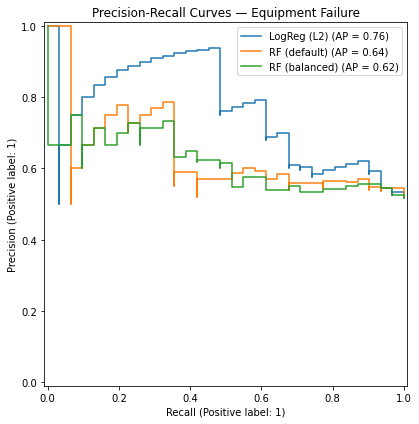

Saved: results/pr_curves.png


In [7]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

os.makedirs("results", exist_ok=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} ({y_train.mean():.1%} failures)")
print(f"Test size:  {X_test.shape[0]} ({y_test.mean():.1%} failures)")

top_models = {
    "LogReg (L2)": LogisticRegression(random_state=42, max_iter=1000),
    "RF (default)": RandomForestClassifier(n_estimators=100, random_state=42),
    "RF (balanced)": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42
    ),
}

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in top_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)

ax.set_title("Precision-Recall Curves — Equipment Failure")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("results/pr_curves.png", dpi=150)
plt.show()
print("Saved: results/pr_curves.png")

---
## Step 6 — Calibration Diagram

A calibration diagram answers: **"When the model says 30% chance of failure, does failure actually occur 30% of the time?"**

- **Perfect calibration** = follows the diagonal line  
- **Above diagonal** = model is underconfident (predicts lower probability than reality)  
- **Below diagonal** = model is overconfident (predicts higher probability than reality)

**Why this matters in production:** If you set an alert threshold at 50%, you assume that 50% = 50%.  
If the model is poorly calibrated, your threshold does not mean what you think it means — the maintenance team cannot trust the risk scores.

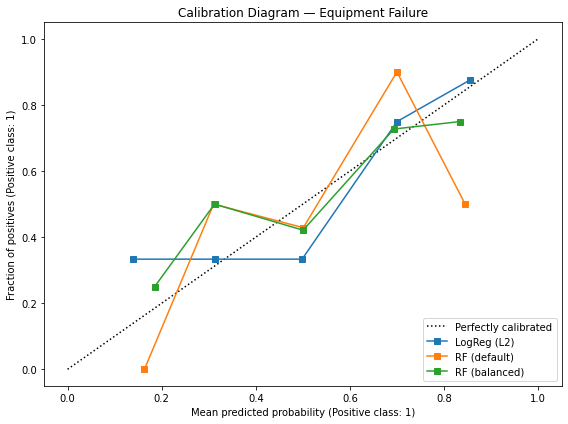

Saved: results/calibration.png

Interpretation:
  - Logistic Regression often calibrates well by design (probabilistic model)
  - Random Forest probabilities are often overconfident (too extreme)
  - RF (balanced) may shift calibration further due to upweighting


In [8]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in top_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    CalibrationDisplay.from_estimator(
        pipe, X_test, y_test, name=name, n_bins=5, ax=ax
    )

ax.set_title("Calibration Diagram — Equipment Failure")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results/calibration.png", dpi=150)
plt.show()
print("Saved: results/calibration.png")
print()
print("Interpretation:")
print("  - Logistic Regression often calibrates well by design (probabilistic model)")
print("  - Random Forest probabilities are often overconfident (too extreme)")
print("  - RF (balanced) may shift calibration further due to upweighting")

---
## Step 7 — Save Best Model with joblib

`joblib.dump` saves the **entire fitted pipeline** — preprocessor and model together — as a single binary file.  
To make predictions on new sensor data in production, you:
1. Load the file with `joblib.load`
2. Call `.predict()` or `.predict_proba()` on raw (unscaled) input DataFrames

The pipeline handles all scaling and encoding automatically.  
This is the simplest form of model deployment — Module 10 will wrap this in a FastAPI service.

In [9]:
import joblib

best_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42
    )),
])
best_pipe.fit(X_train, y_train)

joblib.dump(best_pipe, "results/best_model.joblib")
print(f"Model saved: {os.path.getsize('results/best_model.joblib') / 1024:.0f} KB")

# Verify round-trip: load and confirm identical predictions
loaded_model = joblib.load("results/best_model.joblib")
predictions_match = (loaded_model.predict(X_test) == best_pipe.predict(X_test)).all()
print(f"Loaded model predictions match original: {predictions_match}")

# Show how to use the loaded model on new data
sample_new_reading = X_test.iloc[:3].copy()
print("\nExample: predict on 3 new sensor readings")
print("Predictions:", loaded_model.predict(sample_new_reading))
print("Failure probabilities:", loaded_model.predict_proba(sample_new_reading)[:, 1].round(3))

Model saved: 998 KB
Loaded model predictions match original: True

Example: predict on 3 new sensor readings
Predictions: [0 0 0]
Failure probabilities: [0.14 0.33 0.25]


---
## Step 8 — Export All Results

The five deliverable files in `results/`:

| File | Contents |
|------|----------|
| `comparison_table.csv` | CV metrics for all 6 models |
| `experiment_log.csv` | Full log with hyperparams and timestamps |
| `pr_curves.png` | Precision-Recall curves (saved in Step 5) |
| `calibration.png` | Calibration diagram (saved in Step 6) |
| `best_model.joblib` | Fitted pipeline ready for deployment (saved in Step 7) |

In [10]:
# Save comparison table
results_df.to_csv("results/comparison_table.csv", index=False)
print("Saved: results/comparison_table.csv")

# Save experiment log
log_df = pd.DataFrame(experiment_log)
log_df.to_csv("results/experiment_log.csv", index=False)
print("Saved: results/experiment_log.csv")

# Confirm all 5 deliverables are present
expected_files = [
    "results/comparison_table.csv",
    "results/experiment_log.csv",
    "results/pr_curves.png",
    "results/calibration.png",
    "results/best_model.joblib",
]
print("\nDeliverables check:")
for f in expected_files:
    status = "✓" if os.path.exists(f) else "✗ MISSING"
    size = f"{os.path.getsize(f) / 1024:.0f} KB" if os.path.exists(f) else ""
    print(f"  {status}  {f}  {size}")

Saved: results/comparison_table.csv
Saved: results/experiment_log.csv

Deliverables check:
  ✓  results/comparison_table.csv  0 KB
  ✓  results/experiment_log.csv  2 KB
  ✓  results/pr_curves.png  48 KB
  ✓  results/calibration.png  91 KB
  ✓  results/best_model.joblib  998 KB


---
## Step 9 — Decision Memo Template

The decision memo is **25% of the grade** and is the most important deliverable.  
A memo that says "best accuracy wins" earns Developing. A memo that names a model, cites recall and PR-AUC, explains why recall matters for the use case, and identifies a limitation earns Proficient or Exemplary.

---



---
## Bonus — 3 Techniques to Improve Accuracy, Precision, Recall, and F1

The following three cells demonstrate advanced techniques that directly target the challenges of imbalanced classification:

| Technique | Primary Benefit | How it Works |
|-----------|----------------|--------------|
| **Threshold Optimization** | Maximize F1 or recall without retraining | Move the decision boundary from 0.5 to the optimal cutoff |
| **SMOTE Oversampling** | Better recall and F1 | Synthesize new minority-class samples during training |
| **GridSearchCV Tuning** | Improve all metrics via optimal hyperparameters | Exhaustive search over parameter combinations, scored on F1 |

=== Default threshold (0.5) ===
              precision    recall  f1-score   support

  No Failure       0.56      0.66      0.60        29
     Failure       0.62      0.52      0.56        31

    accuracy                           0.58        60
   macro avg       0.59      0.59      0.58        60
weighted avg       0.59      0.58      0.58        60

=== Optimized threshold (0.250) ===
              precision    recall  f1-score   support

  No Failure       0.75      0.21      0.32        29
     Failure       0.56      0.94      0.70        31

    accuracy                           0.58        60
   macro avg       0.65      0.57      0.51        60
weighted avg       0.65      0.58      0.52        60



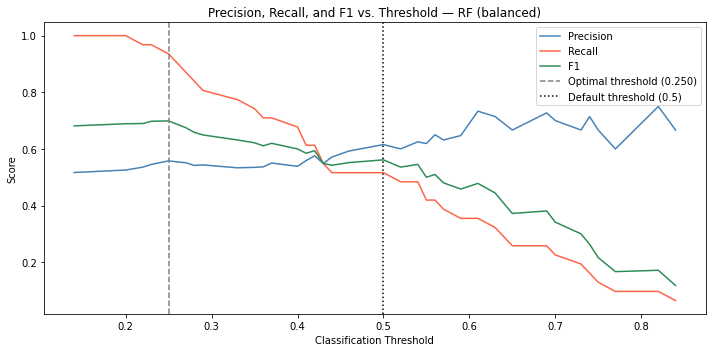

Saved: results/threshold_tuning.png


In [11]:
# ============================================================
# TECHNIQUE 1: Threshold Optimization
# Default threshold is 0.5. Moving it lower raises recall
# at the cost of precision. The optimal threshold maximizes F1.
# ============================================================
from sklearn.metrics import precision_recall_curve, classification_report

# Fit the balanced RF on training data
thresh_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
])
thresh_pipe.fit(X_train, y_train)

# Get predicted probabilities for the positive (failure) class
y_proba = thresh_pipe.predict_proba(X_test)[:, 1]

# Compute precision, recall, and F1 at every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores_at_thresh = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)

best_idx = np.argmax(f1_scores_at_thresh)
best_threshold = thresholds[best_idx]

print("=== Default threshold (0.5) ===")
y_pred_default = (y_proba >= 0.5).astype(int)
print(classification_report(y_test, y_pred_default, target_names=["No Failure", "Failure"]))

print(f"=== Optimized threshold ({best_threshold:.3f}) ===")
y_pred_optimal = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_optimal, target_names=["No Failure", "Failure"]))

# Visualize how metrics change across thresholds
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions[:-1], label="Precision", color="steelblue")
ax.plot(thresholds, recalls[:-1], label="Recall", color="tomato")
ax.plot(thresholds, f1_scores_at_thresh, label="F1", color="seagreen")
ax.axvline(x=best_threshold, color="gray", linestyle="--",
           label=f"Optimal threshold ({best_threshold:.3f})")
ax.axvline(x=0.5, color="black", linestyle=":", label="Default threshold (0.5)")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision, Recall, and F1 vs. Threshold — RF (balanced)")
ax.legend()
plt.tight_layout()
plt.savefig("results/threshold_tuning.png", dpi=150)
plt.show()
print("Saved: results/threshold_tuning.png")

In [12]:
# ============================================================
# TECHNIQUE 2: SMOTE — Synthetic Minority Oversampling
# SMOTE creates synthetic failure samples by interpolating
# between real failures in feature space. Unlike class_weight,
# it changes the training distribution itself.
# Requires: pip install imbalanced-learn
# ============================================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # imblearn's Pipeline supports SMOTE

# imbalanced-learn Pipeline is required because SMOTE must run
# AFTER preprocessing but only on training folds, not test folds.
smote_pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42)),
])

smote_scores = cross_validate(
    smote_pipe, X, y, cv=cv,
    scoring={"accuracy": "accuracy", "precision": "precision",
             "recall": "recall", "f1": "f1"}
)

print("=== SMOTE + RF (default weights) vs. RF (balanced) ===")
print(f"{'Metric':<12} {'SMOTE+RF':>12} {'RF (balanced)':>14}")
print("-" * 40)

rf_balanced_scores = log_df[log_df["model_name"] == "RF (balanced)"].iloc[0]
for metric in ["accuracy", "precision", "recall", "f1"]:
    smote_val = smote_scores[f"test_{metric}"].mean()
    rf_val = rf_balanced_scores[metric]
    print(f"{metric.capitalize():<12} {smote_val:>12.3f} {rf_val:>14.3f}")

print()
print("Key insight:")
print("  SMOTE works by generating new synthetic minority samples,")
print("  while class_weight adjusts the loss function only.")
print("  In practice, their performance is often similar — compare both.")

=== SMOTE + RF (default weights) vs. RF (balanced) ===
Metric           SMOTE+RF  RF (balanced)
----------------------------------------
Accuracy            0.603          0.603
Precision           0.634          0.630
Recall              0.580          0.593
F1                  0.603          0.608

Key insight:
  SMOTE works by generating new synthetic minority samples,
  while class_weight adjusts the loss function only.
  In practice, their performance is often similar — compare both.


In [13]:
# ============================================================
# TECHNIQUE 3: GridSearchCV — Systematic Hyperparameter Search
# Exhaustively tests every combination of parameters and selects
# the one that maximizes F1 on held-out folds.
# Scoring='f1' ensures we optimize for minority class performance,
# not accuracy — critical for imbalanced datasets.
# ============================================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 5],
    "model__class_weight": ["balanced", None],
}

tuning_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42)),
])

grid_search = GridSearchCV(
    tuning_pipe,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",          # optimize for F1, not accuracy
    n_jobs=-1,             # use all available CPU cores
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f"Best CV F1:   {grid_search.best_score_:.3f}")
print(f"Best params:  {grid_search.best_params_}")

print("\nTest set performance with tuned model:")
y_pred_tuned = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_tuned, target_names=["No Failure", "Failure"]))

# Compare tuned vs. default RF (balanced)
from sklearn.metrics import f1_score
y_pred_baseline = best_pipe.predict(X_test)
f1_baseline = f1_score(y_test, y_pred_baseline)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"\nF1 improvement from tuning: {f1_baseline:.3f} → {f1_tuned:.3f} (+{f1_tuned - f1_baseline:.3f})")

# Save tuned model
joblib.dump(grid_search.best_estimator_, "results/best_model_tuned.joblib")
print("Saved: results/best_model_tuned.joblib")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: inv

Best CV F1:   0.705
Best params:  {'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}

Test set performance with tuned model:
              precision    recall  f1-score   support

  No Failure       0.53      0.59      0.56        29
     Failure       0.57      0.52      0.54        31

    accuracy                           0.55        60
   macro avg       0.55      0.55      0.55        60
weighted avg       0.55      0.55      0.55        60


F1 improvement from tuning: 0.536 → 0.542 (+0.007)
Saved: results/best_model_tuned.joblib
